# Toggle Switch

In [13]:
import numpy as np
from scipy.stats import truncnorm

In [27]:
alpha1 = 22.
alpha2 = 12.
beta1 = 4.
beta2 = 4.5 

mu = 325.
sigma = .25
gamma = .15

n = 2000
T = 300
scale_uv = 0.5

us, vs = np.zeros((n, T)), np.zeros((n, T))

us[:, 0] = 10.
vs[:, 0] = 10.

for t in range(1, T):
    for i in range(n):
        u = us[i, t-1]
        v = vs[i, t-1]
        mean_u = u + alpha1 / (1 + v**beta1) - (1 + 0.03*u)
        mean_v = v + alpha2 / (1 + u**beta2) - (1 + 0.03*v)
        us[i, t] = truncnorm.rvs(loc = mean_u, scale = scale_uv, a = (0 - mean_u)/scale_uv, b = np.inf)
        vs[i, t] = truncnorm.rvs(loc = mean_v, scale = scale_uv, a = (0 - mean_v)/scale_uv, b = np.inf)

y = np.zeros(n)
for i in range(n):
    u = us[i, -1]
    v = vs[i, -1]
    mean_y = mu + u
    scale_y = sigma*mu/(u**gamma)
    y[i] = truncnorm.rvs(loc = mean_y, scale = scale_y, a = (0 - mean_y)/scale_y, b = np.inf)

In [28]:
print("us: max =", np.max(us), ", min =", np.min(us))
print("vs: max =", np.max(vs), ", min =", np.min(vs))
print("y: max =", np.max(y), ", min =", np.min(y))

us: max = 700.4139348103863 , min = 3.5747205917591174e-07
vs: max = 370.82716475446574 , min = 4.0701257009168046e-07
y: max = 1121.024720676896 , min = 10.61372324184913


 ...]

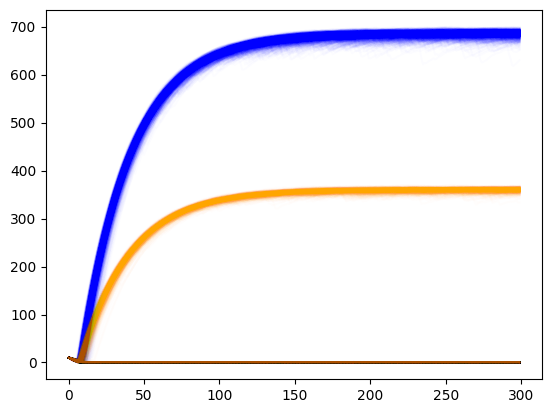

In [29]:
plt.plot(us.T, color = 'blue', alpha = 0.01)
plt.plot(vs.T, color = 'orange', alpha = 0.01)

(array([  6.,   7.,  17.,  19.,  47.,  66.,  74.,  85.,  71.,  86.,  78.,
         65.,  43.,  19.,  14.,   5.,   2.,   4.,   2.,   0.,   0.,   0.,
          0.,   0.,  11., 153., 485., 479., 140.,  22.]),
 array([  10.61372324,   47.62742316,   84.64112307,  121.65482299,
         158.6685229 ,  195.68222281,  232.69592273,  269.70962264,
         306.72332256,  343.73702247,  380.75072239,  417.7644223 ,
         454.77812222,  491.79182213,  528.80552204,  565.81922196,
         602.83292187,  639.84662179,  676.8603217 ,  713.87402162,
         750.88772153,  787.90142145,  824.91512136,  861.92882128,
         898.94252119,  935.9562211 ,  972.96992102, 1009.98362093,
        1046.99732085, 1084.01102076, 1121.02472068]),
 <BarContainer object of 30 artists>)

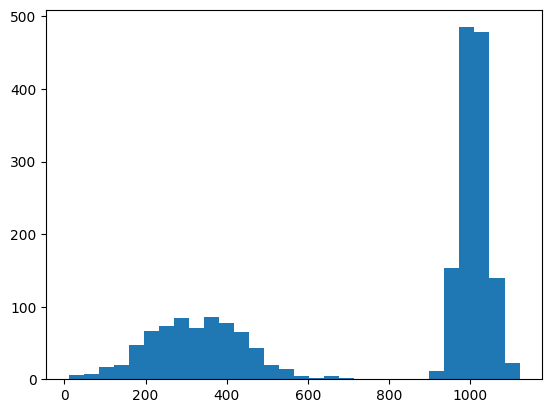

In [30]:
import matplotlib.pyplot as plt

plt.hist(y, bins = 30)

array([ -71.78984891,  -75.78663062,  -70.01073622, ..., -176.36096732,
        -34.40010832,  -24.98189395])